## Overview
This project focuses on tumor classification using ultrasound images. 
The goal is to build models that can distinguish between benign and malignant cases.

The workflow includes:
- Data preprocessing
- Model training
- Evaluation and comparison of results

Tools: Python, scikit-learn, TensorFlow/PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as F
import urllib.parse
import os
import numpy as np

In [ ]:
# transform = transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize the image to the input size required by ResNet
#     transforms.ToTensor(),
#     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Normalize with ImageNet mean and std
# ])

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(degrees=15),
    # transforms.RandomApply([
    #     transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0),
    #     transforms.GaussianBlur(kernel_size=3, sigma=(10.0, 50.0)),
    # ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Specify the path to your dataset external_data
data_dir = "data"
val_data_dir = "external_data"

# Create an ImageFolder dataset instance
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=transform)

# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create DataLoader instances for training and testing
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
def visualize_tumor_predictions(loader, model, num_images=5):
    images, labels = next(iter(loader))
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    num_images = min(num_images, len(images))

    fig_width = 10
    fig_height = num_images * 2

    fig, axs = plt.subplots(nrows=num_images, ncols=1, figsize=(fig_width, fig_height))
    fig.subplots_adjust(hspace=0.5)

    if num_images == 1:
        axs = [axs]

    idx_to_class = {0: 'Benign', 1: 'Malignant'}

    for i in range(num_images):
        img = images[i].cpu().data.numpy().transpose((1, 2, 0))

        #  unnormalization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        ax = axs[i] if num_images > 1 else axs
        ax.imshow(img)
        ax.axis('off')

        image_path, _ = loader.dataset.samples[i]
        image_name = os.path.basename(image_path)

        image_name = urllib.parse.unquote(image_name)

        # title
        axs[i].set_title(f"Image: {image_name}", fontsize=8,pad=20)


        true_label = idx_to_class[labels[i].item()]
        pred_label = idx_to_class[predicted[i].item()]

        # green for correct, red for incorrect
        box_color = 'green' if labels[i] == predicted[i] else 'red'

        rect = patches.Rectangle((0, 0), img.shape[1], img.shape[0], linewidth=2, edgecolor=box_color, facecolor='none')
        ax.add_patch(rect)

        correctness = "Correct" if labels[i] == predicted[i] else "Incorrect"
        ax.text(0, -2, f'{correctness}: True - {true_label}, Pred - {pred_label}', fontsize=10, color=box_color)

    plt.tight_layout()
    plt.show()

In [ ]:
# Define a simple convolutional neural network
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, len(dataset.classes))

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(-1, 64 * 16 * 16)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Instantiate the model, loss function, and optimizer
# model = SimpleCNN()
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')

In [ ]:
# Evaluate the model on the test set
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
# Instantiate your model
print('SimpleCNN')
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize variables for tracking the best model
best_accuracy = 0.0
best_model_state = None

# Training loop
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:  # Print every 200 batches
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
            running_loss = 0.0

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f'Test Accuracy after epoch {epoch + 1}: {accuracy:.4f}')
    
    # Check if current model is the best performing so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = model.state_dict().copy()

    model.train()  # Set the model back to training mode

print('Finished Training')

# Load the best performing model parameters
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'Best performing model loaded with test accuracy: {best_accuracy:.4f}')

    # Save the best model
    torch.save(model.state_dict(), 'best_classification_models/SimpleCNN.pth')
    print('Best model saved.')
else:
    print('No improvement on Test accuracy during training.')


# Evaluate the best model on the test set
correct = 0
total = 0
all_labels = []
all_predictions = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    for inputs, labels in validation_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct / total
print(f'Accuracy on the Validation set: {accuracy * 100:.2f}%')

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

SimpleCNN
Epoch 1, Batch 200, Loss: 0.651
Test Accuracy after epoch 1: 0.6739
Epoch 2, Batch 200, Loss: 0.545
Test Accuracy after epoch 2: 0.7348
Epoch 3, Batch 200, Loss: 0.464
Test Accuracy after epoch 3: 0.7609
Epoch 4, Batch 200, Loss: 0.385
Test Accuracy after epoch 4: 0.8087
Epoch 5, Batch 200, Loss: 0.261
Test Accuracy after epoch 5: 0.7739
Epoch 6, Batch 200, Loss: 0.199
Test Accuracy after epoch 6: 0.8348
Epoch 7, Batch 200, Loss: 0.124
Test Accuracy after epoch 7: 0.8304
Epoch 8, Batch 200, Loss: 0.052
Test Accuracy after epoch 8: 0.8261
Epoch 9, Batch 200, Loss: 0.077
Test Accuracy after epoch 9: 0.7826
Epoch 10, Batch 200, Loss: 0.019
Test Accuracy after epoch 10: 0.8304
Epoch 11, Batch 200, Loss: 0.024
Test Accuracy after epoch 11: 0.8217
Epoch 12, Batch 200, Loss: 0.005
Test Accuracy after epoch 12: 0.8261
Epoch 13, Batch 200, Loss: 0.001
Test Accuracy after epoch 13: 0.8304
Epoch 14, Batch 200, Loss: 0.000
Test Accuracy after epoch 14: 0.8348
Epoch 15, Batch 200, Loss: 0

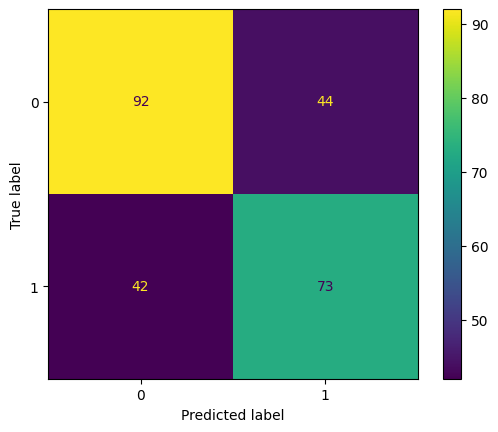

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_predictions))
disp.plot()
plt.show()

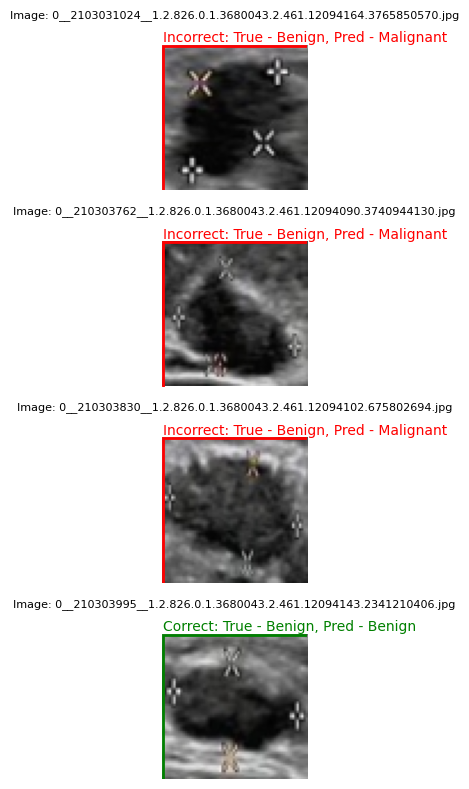

In [ ]:
visualize_tumor_predictions(validation_loader, model, num_images=5)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to the input size required by ResNet
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(degrees=15),
    # transforms.RandomApply([
    #     transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0),
    #     transforms.GaussianBlur(kernel_size=3, sigma=(10.0, 50.0)),
    # ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Normalize with ImageNet mean and std
])

# Specify the path to your dataset
data_dir = "data"
val_data_dir = "external_data"

# Create an ImageFolder dataset instance
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=transform)

# Split the dataset into training and testing sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create DataLoader instances for training and testing
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# # Load pre-trained ResNet model
# resnet_model = models.resnet18(pretrained=True)

# # Modify the output layer to match the number of classes in your dataset
# num_classes = len(dataset.classes)
# resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

# # Set the model to training mode
# resnet_model.train()

# # Instantiate the loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

In [ ]:
# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs = resnet_model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')

In [ ]:
# # Evaluate the model on the test set
# resnet_model.eval()
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = resnet_model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
# Load pre-trained ResNet model
print('resnet18')
resnet_model = models.resnet18(pretrained=True)

# Modify the output layer to match the number of classes in your dataset
num_classes = len(dataset.classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

# Set the model to training mode
resnet_model.train()

# Instantiate the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

# Initialize variables for tracking the best model
best_accuracy = 0.0
best_model_state = None

# Training loop
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:  # Print every 200 batches
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
            running_loss = 0.0

    # Validation loop (you need to define validation_loader)
    resnet_model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = resnet_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f'Test Accuracy after epoch {epoch + 1}: {accuracy:.4f}')
    
    # Check if current model is the best performing so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = resnet_model.state_dict().copy()

    resnet_model.train()  # Set the model back to training mode

print('Finished Training')

# Load the best performing model parameters
if best_model_state is not None:
    resnet_model.load_state_dict(best_model_state)
    print(f'Best performing model loaded with Test accuracy: {best_accuracy:.4f}')
    
    # Save the best model
    torch.save(resnet_model.state_dict(), 'best_classification_models/resnet18.pth')
    print('Best model saved.')

else:
    print('No improvement on validation accuracy during training.')

# Evaluate the best model on the validation set
resnet_model.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in validation_loader:
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct / total
print(f'Accuracy on the validation set: {accuracy * 100:.2f}%')

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')


resnet18


/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Batch 200, Loss: 0.680
Test Accuracy after epoch 1: 0.6913
Epoch 2, Batch 200, Loss: 0.544
Test Accuracy after epoch 2: 0.7000
Epoch 3, Batch 200, Loss: 0.481
Test Accuracy after epoch 3: 0.8478
Epoch 4, Batch 200, Loss: 0.442
Test Accuracy after epoch 4: 0.8000
Epoch 5, Batch 200, Loss: 0.406
Test Accuracy after epoch 5: 0.7304
Epoch 6, Batch 200, Loss: 0.438
Test Accuracy after epoch 6: 0.9000
Epoch 7, Batch 200, Loss: 0.447
Test Accuracy after epoch 7: 0.8739
Epoch 8, Batch 200, Loss: 0.332
Test Accuracy after epoch 8: 0.8478
Epoch 9, Batch 200, Loss: 0.304
Test Accuracy after epoch 9: 0.8739
Epoch 10, Batch 200, Loss: 0.377
Test Accuracy after epoch 10: 0.9304
Epoch 11, Batch 200, Loss: 0.329
Test Accuracy after epoch 11: 0.8783
Epoch 12, Batch 200, Loss: 0.257
Test Accuracy after epoch 12: 0.9000
Epoch 13, Batch 200, Loss: 0.252
Test Accuracy after epoch 13: 0.9087
Epoch 14, Batch 200, Loss: 0.273
Test Accuracy after epoch 14: 0.8435
Epoch 15, Batch 200, Loss: 0.216
Test 

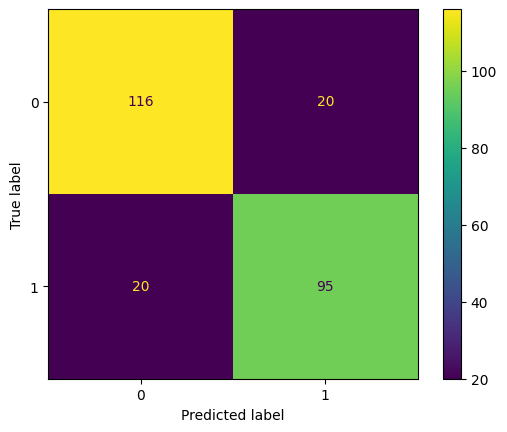

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_predictions))
disp.plot()
plt.show()

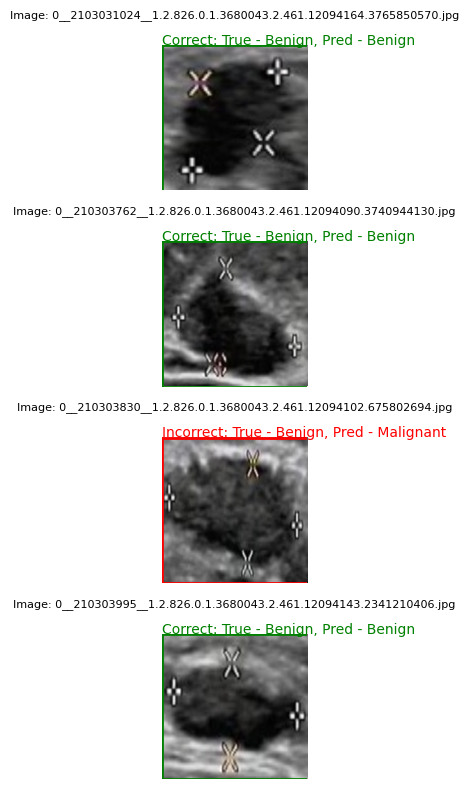

In [ ]:
visualize_tumor_predictions(validation_loader, resnet_model, num_images=5)

In [ ]:
# # Load pre-trained DenseNet model
# densenet_model = models.densenet121(pretrained=True)

# # Modify the output layer to match the number of classes in your dataset
# num_classes = len(dataset.classes)
# densenet_model.classifier = nn.Linear(densenet_model.classifier.in_features, num_classes)

# # Set the model to training mode
# densenet_model.train()

# # Instantiate the loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(densenet_model.parameters(), lr=0.001)

In [ ]:
# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs = densenet_model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')

In [ ]:
# # Evaluate the model on the test set
# densenet_model.eval()
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = densenet_model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
print('densenet121')

# Load pre-trained DenseNet model
densenet_model = models.densenet121(pretrained=True)

# Modify the output layer to match the number of classes in your dataset
num_classes = len(dataset.classes)
densenet_model.classifier = nn.Linear(densenet_model.classifier.in_features, num_classes)

# Set the model to training mode
densenet_model.train()

# Instantiate the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(densenet_model.parameters(), lr=0.001)

# Initialize variables for tracking the best model
best_accuracy = 0.0
best_model_state = None

# Training loop
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()
        outputs = densenet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:  # Print every 200 batches
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
            running_loss = 0.0

    # Validation loop (you need to define validation_loader)
    densenet_model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = densenet_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f'Test Accuracy after epoch {epoch + 1}: {accuracy:.4f}')
    
    # Check if current model is the best performing so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = densenet_model.state_dict().copy()

    densenet_model.train()  # Set the model back to training mode

print('Finished Training')

# Load the best performing model parameters
if best_model_state is not None:
    densenet_model.load_state_dict(best_model_state)
    print(f'Best performing model loaded with Test accuracy: {best_accuracy:.4f}')
    
    # Save the best model
    torch.save(densenet_model.state_dict(), 'best_classification_models/densenet121.pth')
    print('Best DenseNet model saved.')

else:
    print('No improvement on validation accuracy during training.')

# Evaluate the best model on the validation set
densenet_model.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in validation_loader:
        outputs = densenet_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct / total
print(f'Accuracy on the validation set: {accuracy * 100:.2f}%')

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')


densenet121


/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Batch 200, Loss: 0.603
Test Accuracy after epoch 1: 0.7565
Epoch 2, Batch 200, Loss: 0.571
Test Accuracy after epoch 2: 0.6870
Epoch 3, Batch 200, Loss: 0.553
Test Accuracy after epoch 3: 0.8130
Epoch 4, Batch 200, Loss: 0.475
Test Accuracy after epoch 4: 0.6217
Epoch 5, Batch 200, Loss: 0.458
Test Accuracy after epoch 5: 0.7913
Epoch 6, Batch 200, Loss: 0.462
Test Accuracy after epoch 6: 0.8565
Epoch 7, Batch 200, Loss: 0.427
Test Accuracy after epoch 7: 0.8174
Epoch 8, Batch 200, Loss: 0.448
Test Accuracy after epoch 8: 0.8435
Epoch 9, Batch 200, Loss: 0.392
Test Accuracy after epoch 9: 0.6957
Epoch 10, Batch 200, Loss: 0.385
Test Accuracy after epoch 10: 0.8478
Epoch 11, Batch 200, Loss: 0.381
Test Accuracy after epoch 11: 0.8130
Epoch 12, Batch 200, Loss: 0.373
Test Accuracy after epoch 12: 0.7870
Epoch 13, Batch 200, Loss: 0.384
Test Accuracy after epoch 13: 0.8870
Epoch 14, Batch 200, Loss: 0.379
Test Accuracy after epoch 14: 0.9087
Epoch 15, Batch 200, Loss: 0.381
Test 

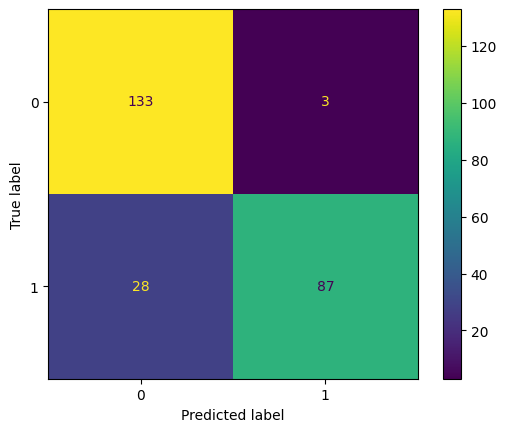

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_predictions))
disp.plot()
plt.show()

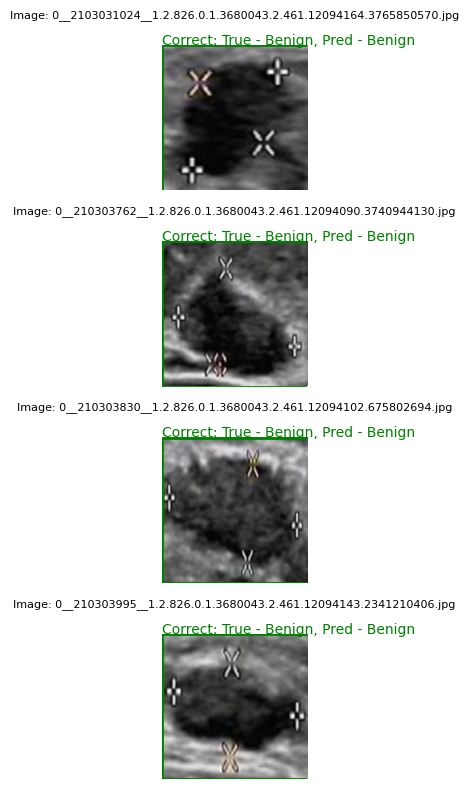

In [ ]:
visualize_tumor_predictions(validation_loader, densenet_model, num_images=5)

In [ ]:
# # Load pre-trained MobileNetV2 model
# mobilenet_model = models.mobilenet_v2(pretrained=True)

# # Modify the output layer to match the number of classes in your dataset
# num_classes = len(dataset.classes)
# mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.classifier[1].in_features, num_classes)

# # Set the model to training mode
# mobilenet_model.train()

# # Instantiate the loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(mobilenet_model.parameters(), lr=0.001)

In [ ]:
# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs = mobilenet_model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')


In [ ]:
# # Evaluate the model on the test set
# mobilenet_model.eval()
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = mobilenet_model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
print('mobilenetv2')
# Load pre-trained MobileNetV2 model
mobilenet_model = models.mobilenet_v2(pretrained=True)

# Modify the output layer to match the number of classes in your dataset
num_classes = len(dataset.classes)
mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.classifier[1].in_features, num_classes)

# Set the model to training mode
mobilenet_model.train()

# Instantiate the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_model.parameters(), lr=0.001)

# Initialize variables for tracking the best model
best_accuracy = 0.0
best_model_state = None

# Training loop
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()
        outputs = mobilenet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:  # Print every 200 batches
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
            running_loss = 0.0

    # Validation loop (you need to define validation_loader)
    mobilenet_model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = mobilenet_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f'Test Accuracy after epoch {epoch + 1}: {accuracy:.4f}')
    
    # Check if current model is the best performing so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = mobilenet_model.state_dict().copy()

    mobilenet_model.train()  # Set the model back to training mode

print('Finished Training')

# Load the best performing model parameters
if best_model_state is not None:
    mobilenet_model.load_state_dict(best_model_state)
    print(f'Best performing model loaded with Test accuracy: {best_accuracy:.4f}')
    
    # Save the best model
    torch.save(mobilenet_model.state_dict(), 'best_classification_models/best_mobilenet_model.pth')
    print('Best MobileNetV2 model saved.')

else:
    print('No improvement on validation accuracy during training.')

# Evaluate the best model on the validation set
mobilenet_model.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in validation_loader:
        outputs = mobilenet_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct / total
print(f'Accuracy on the validation set: {accuracy * 100:.2f}%')

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')



mobilenetv2


/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Batch 200, Loss: 0.544
Test Accuracy after epoch 1: 0.8826
Epoch 2, Batch 200, Loss: 0.493
Test Accuracy after epoch 2: 0.8696
Epoch 3, Batch 200, Loss: 0.415
Test Accuracy after epoch 3: 0.8826
Epoch 4, Batch 200, Loss: 0.386
Test Accuracy after epoch 4: 0.8565
Epoch 5, Batch 200, Loss: 0.336
Test Accuracy after epoch 5: 0.9174
Epoch 6, Batch 200, Loss: 0.361
Test Accuracy after epoch 6: 0.9087
Epoch 7, Batch 200, Loss: 0.330
Test Accuracy after epoch 7: 0.9217
Epoch 8, Batch 200, Loss: 0.328
Test Accuracy after epoch 8: 0.9174
Epoch 9, Batch 200, Loss: 0.331
Test Accuracy after epoch 9: 0.8304
Epoch 10, Batch 200, Loss: 0.294
Test Accuracy after epoch 10: 0.8522
Epoch 11, Batch 200, Loss: 0.298
Test Accuracy after epoch 11: 0.9217
Epoch 12, Batch 200, Loss: 0.264
Test Accuracy after epoch 12: 0.8609
Epoch 13, Batch 200, Loss: 0.244
Test Accuracy after epoch 13: 0.9261
Epoch 14, Batch 200, Loss: 0.186
Test Accuracy after epoch 14: 0.9261
Epoch 15, Batch 200, Loss: 0.167
Test 

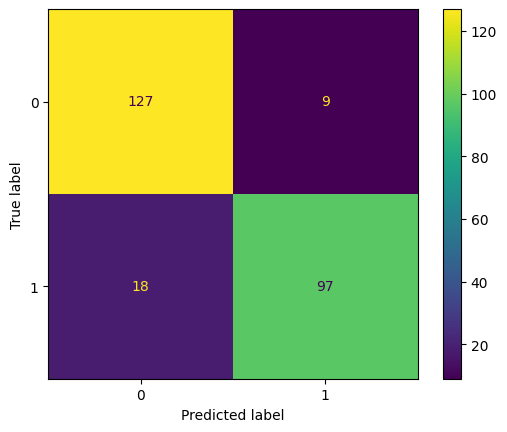

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_predictions))
disp.plot()
plt.show()

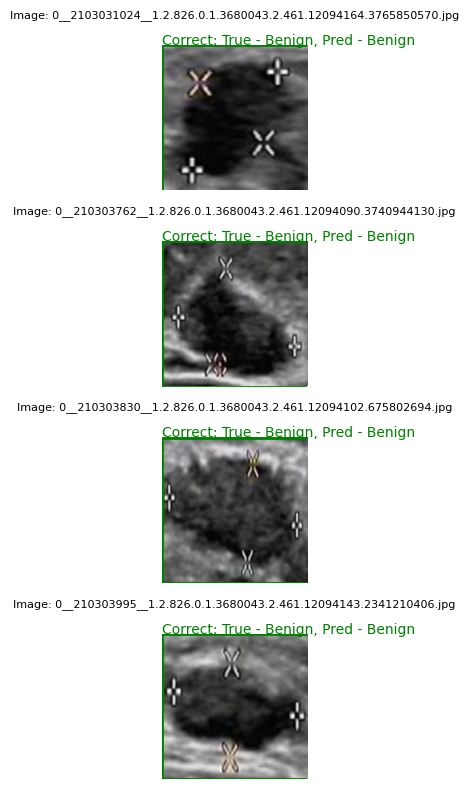

In [ ]:
visualize_tumor_predictions(validation_loader, mobilenet_model, num_images=5)

In [ ]:
# # Load pre-trained VGG16 model
# vgg_model = models.vgg16(pretrained=True)

# # Modify the output layer to match the number of classes in your dataset
# num_classes = len(dataset.classes)
# vgg_model.classifier[-1] = nn.Linear(vgg_model.classifier[-1].in_features, num_classes)

# # Set the model to training mode
# vgg_model.train()

# # Instantiate the loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(vgg_model.parameters(), lr=0.001)

In [ ]:
# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs = vgg_model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')

In [ ]:
# # Evaluate the model on the test set
# vgg_model.eval()
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = vgg_model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
# Load pre-trained VGG16 model
print('vgg')
vgg_model = models.vgg16(pretrained=True)

# Modify the output layer to match the number of classes in your dataset
num_classes = len(dataset.classes)
vgg_model.classifier[-1] = nn.Linear(vgg_model.classifier[-1].in_features, num_classes)

# Set the model to training mode
vgg_model.train()

# Instantiate the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=0.001)

# Initialize variables for tracking the best model
best_accuracy = 0.0
best_model_state = None

# Training loop
epochs = 20
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()
        outputs = vgg_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 200 == 199:  # Print every 200 batches
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
            running_loss = 0.0

    # Validation loop (you need to define validation_loader)
    vgg_model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = vgg_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    print(f'Test Accuracy after epoch {epoch + 1}: {accuracy:.4f}')
    
    # Check if current model is the best performing so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = vgg_model.state_dict().copy()

    vgg_model.train()  # Set the model back to training mode

print('Finished Training')

# Load the best performing model parameters
if best_model_state is not None:
    vgg_model.load_state_dict(best_model_state)
    print(f'Best performing model loaded with Test accuracy: {best_accuracy:.4f}')
    
    # Save the best model
    torch.save(vgg_model.state_dict(), 'best_classification_models/best_vgg_model.pth')
    print('Best VGG16 model saved.')

else:
    print('No improvement on validation accuracy during training.')

# Evaluate the best model on the validation set
vgg_model.eval()
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in validation_loader:
        outputs = vgg_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = correct / total
print(f'Accuracy on the validation set: {accuracy * 100:.2f}%')

precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')


vgg


/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Batch 200, Loss: 0.837
Test Accuracy after epoch 1: 0.5870
Epoch 2, Batch 200, Loss: 0.743
Test Accuracy after epoch 2: 0.5870
Epoch 3, Batch 200, Loss: 0.694
Test Accuracy after epoch 3: 0.5870
Epoch 4, Batch 200, Loss: 0.705
Test Accuracy after epoch 4: 0.5870
Epoch 5, Batch 200, Loss: 0.696
Test Accuracy after epoch 5: 0.5870
Epoch 6, Batch 200, Loss: 0.701
Test Accuracy after epoch 6: 0.5870
Epoch 7, Batch 200, Loss: 0.695
Test Accuracy after epoch 7: 0.5870
Epoch 8, Batch 200, Loss: 0.689
Test Accuracy after epoch 8: 0.5870
Epoch 9, Batch 200, Loss: 0.694
Test Accuracy after epoch 9: 0.5870
Epoch 10, Batch 200, Loss: 0.691
Test Accuracy after epoch 10: 0.5870
Epoch 11, Batch 200, Loss: 0.685
Test Accuracy after epoch 11: 0.5870
Epoch 12, Batch 200, Loss: 0.693
Test Accuracy after epoch 12: 0.5870
Epoch 13, Batch 200, Loss: 0.687
Test Accuracy after epoch 13: 0.4130
Epoch 14, Batch 200, Loss: 0.693
Test Accuracy after epoch 14: 0.5870
Epoch 15, Batch 200, Loss: 0.689
Test 

/Users/patrickwang/PycharmProjects/capstone/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


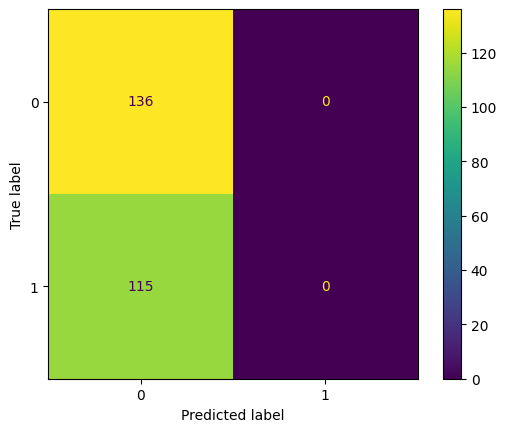

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_predictions))
disp.plot()
plt.show()

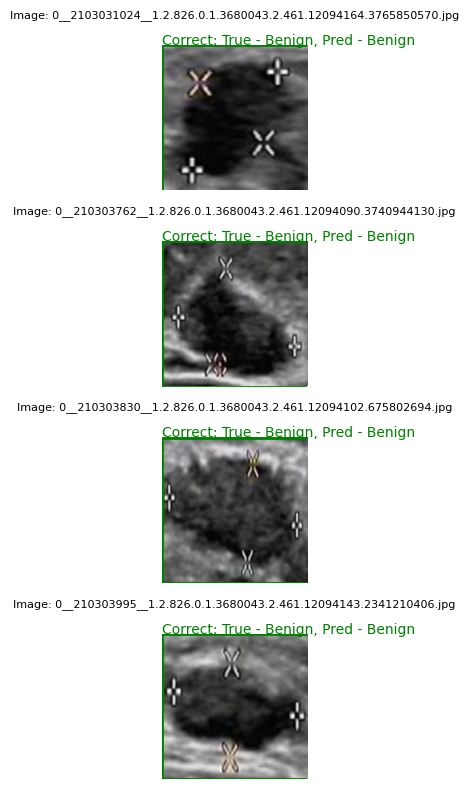

In [ ]:
visualize_tumor_predictions(validation_loader, vgg_model, num_images=5)

In [ ]:
# transform = transforms.Compose([
#     transforms.Resize((299, 299)),  # Resize the image to the input size required by ResNet
#     # transforms.RandomHorizontalFlip(p=0.5),
#     # transforms.RandomVerticalFlip(p=0.5),
#     # transforms.RandomRotation(degrees=15),
#     # transforms.RandomApply([
#     #     transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0),
#     #     transforms.GaussianBlur(kernel_size=3, sigma=(10.0, 50.0)),
#     # ], p=0.5),
#     transforms.ToTensor(),
#     transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # Normalize with ImageNet mean and std
# ])

# # Specify the path to your dataset
# data_dir = "data"

# # Create an ImageFolder dataset instance
# dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# # Split the dataset into training and testing sets
# train_size = int(0.8 * len(dataset))
# test_size = len(dataset) - train_size
# train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# # Create DataLoader instances for training and testing
# batch_size = 4
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# # Load pre-trained Inception v3 model
# inception_model = models.inception_v3(pretrained=True)

# # Modify the output layer to match the number of classes in your dataset
# num_classes = len(dataset.classes)
# inception_model.fc = nn.Linear(inception_model.fc.in_features, num_classes)

# # Set the model to training mode
# inception_model.train()

# # Instantiate the loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(inception_model.parameters(), lr=0.001)

In [ ]:
# # Training loop
# epochs = 5
# for epoch in range(epochs):
#     running_loss = 0.0
#     for i, (inputs, labels) in enumerate(train_loader, 0):
#         optimizer.zero_grad()
#         outputs, aux_outputs = inception_model(inputs)
#         loss = criterion(outputs, labels) + 0.4 * criterion(aux_outputs, labels)  # Inception v3 has auxiliary outputs
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#         if i % 200 == 199:  # Print every 200 batches
#             print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 200:.3f}')
#             running_loss = 0.0

# print('Finished Training')

In [ ]:
# # Evaluate the model on the test set
# inception_model.eval()
# correct = 0
# total = 0
# all_labels = []
# all_predictions = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs, _ = inception_model(inputs)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
#         all_labels.extend(labels.cpu().numpy())
#         all_predictions.extend(predicted.cpu().numpy())

# accuracy = correct / total
# print(f'Accuracy on the test set: {accuracy * 100:.2f}%')

# precision = precision_score(all_labels, all_predictions, average='weighted')
# recall = recall_score(all_labels, all_predictions, average='weighted')
# f1 = f1_score(all_labels, all_predictions, average='weighted')

# print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

In [ ]:
import os
import json
import pandas as pd
pd.set_option('display.max_columns', None)

# Path to your folder containing JSON files
folder_path = 'Ultrasound/'

# Function to recursively search for JSON files and extract 'scores' key with file paths
def read_json_files(folder_path):
    scores_list = []
    file_paths = []
    for root, _, filenames in os.walk(folder_path):
        for filename in filenames:
            if filename.endswith('.json'):
                with open(os.path.join(root, filename), 'r') as file:
                    data = json.load(file)
                    if 'confidence_score' in data:
                        scores = data['confidence_score']
                        scores_list.append(scores)
                        file_paths.append(os.path.join(root, filename))
    return scores_list, file_paths

# Read JSON files and extract 'scores' key with file paths
scores_data, file_paths = read_json_files(folder_path)

# Create DataFrame
df = pd.DataFrame({'confidence_score': scores_data, 'file_path': file_paths})

# Print or manipulate the DataFrame as needed
print(df)


      confidence_score                                          file_path
0             0.981844  Ultrasound/malignant/13228259/20201212112404.json
1             0.968238  Ultrasound/malignant/13228259/20201212112331.json
2             0.981452  Ultrasound/malignant/13100040/20180530095939.json
3             0.987525  Ultrasound/malignant/13123606/20181113113813.json
4             0.977843  Ultrasound/malignant/13123606/20181113113531.json
...                ...                                                ...
1143          0.989579     Ultrasound/benign/13158713/20190725152449.json
1144          0.974937     Ultrasound/benign/13143169/20190413101800.json
1145          0.977260           Ultrasound/benign/13222388/I0081811.json
1146          0.974791     Ultrasound/benign/13189671/20200411102758.json
1147          0.982755     Ultrasound/benign/13145067/20180425153233.json

[1148 rows x 2 columns]


In [ ]:
df[df['confidence_score'] < 0.5]

,confidence_score,file_path
21,0.358242,Ultrasound/malignant/13224665/3CF829CF58E643F1...
24,0.468398,Ultrasound/malignant/1396156/20180427084800.json
46,0.469651,Ultrasound/malignant/13228377/20201121163346.json
464,0.489696,Ultrasound/malignant/13240364/I0129972.json
521,0.139034,Ultrasound/benign/13162838/20190821094655.json
860,0.475442,Ultrasound/benign/13159281/20190719121647.json
893,0.493077,Ultrasound/benign/13202021/20200710090204.json
960,0.470826,Ultrasound/benign/2121919174/I0283658.json
1075,0.413112,Ultrasound/benign/13167309/20190519155114.json
1077,0.126008,Ultrasound/benign/13167309/20190519155126.json


In [ ]:
['External_test_set/malignant/201811141628/3B8AD6EB99C3477984402F7D633DF506_2073429.jpg', 'External_test_set/benign/2105191642/B1EEDC0FCCAA4679BC9DBA6E2BE75FD0_7156786.jpg']


['External_test_set/malignant/201811141628/3B8AD6EB99C3477984402F7D633DF506_2073429.jpg',
 'External_test_set/benign/2105191642/B1EEDC0FCCAA4679BC9DBA6E2BE75FD0_7156786.jpg']

In [ ]:
folder_path = 'External_test_set/'

# Function to recursively search for JSON files and extract 'scores' key with file paths
def read_json_files(folder_path):
    scores_list = []
    file_paths = []
    for root, _, filenames in os.walk(folder_path):
        for filename in filenames:
            if filename.endswith('.json'):
                with open(os.path.join(root, filename), 'r') as file:
                    data = json.load(file)
                    if 'confidence_score' in data:
                        scores = data['confidence_score']
                        scores_list.append(scores)
                        file_paths.append(os.path.join(root, filename))
    return scores_list, file_paths

# Read JSON files and extract 'scores' key with file paths
scores_data, file_paths = read_json_files(folder_path)

# Create DataFrame
df = pd.DataFrame({'confidence_score': scores_data, 'file_path': file_paths})

# Print or manipulate the DataFrame as needed
print(df)

     confidence_score                                          file_path
0            0.984231  External_test_set/malignant/201903291241/B411B...
1            0.957554  External_test_set/malignant/201903291241/B411B...
2            0.989900  External_test_set/malignant/201903291241/B411B...
3            0.983292  External_test_set/malignant/201903291241/B411B...
4            0.984715  External_test_set/malignant/201903291241/B411B...
..                ...                                                ...
244          0.955176  External_test_set/benign/210929953/1.2.826.0.1...
245          0.803664  External_test_set/benign/210929953/1.2.826.0.1...
246          0.943517  External_test_set/benign/210929953/1.2.826.0.1...
247          0.969836  External_test_set/benign/211201682/1.2.826.0.1...
248          0.939317  External_test_set/benign/210310787/1.2.826.0.1...

[249 rows x 2 columns]


In [ ]:
pd.set_option('display.max_colwidth', None)


print(df[df['confidence_score'] < 0.5])

     confidence_score  \
20           0.180992   
36           0.079742   
62           0.279451   
117          0.381743   
133          0.437493   
151          0.084159   
167          0.489528   
185          0.331634   
186          0.415583   
194          0.203979   
216          0.147477   

                                                                                        file_path  
20   External_test_set/malignant/201904092067/52A58D887E0E43C29155FA9348704EFA_31495531_pred.json  
36    External_test_set/malignant/201811141628/3B8AD6EB99C3477984402F7D633DF506_2073397_pred.json  
62   External_test_set/malignant/201901210441/710850E78E534525AFDFB8C8F9FC5466_25558153_pred.json  
117    External_test_set/benign/211006575/1.2.826.0.1.3680043.2.461.12538471.4202910759_pred.json  
133     External_test_set/benign/211124679/1.2.826.0.1.3680043.2.461.12638840.163889883_pred.json  
151        External_test_set/benign/2105191642/B1EEDC0FCCAA4679BC9DBA6E2BE75FD0_7156641_pred.json  